In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
import math

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

from yellowbrick.target import FeatureCorrelation

##### Houses DataBase

In [ ]:
houses_size = np.array([30, 39, 49, 60])

houses_price = np.array([57000, 69000, 77000, 90000])

houses_dataset = pd.DataFrame({"size": houses_size, "price": houses_price})

houses_dataset.head()

,size,price
0,30,57000
1,39,69000
2,49,77000
3,60,90000


##### Manual mode

In [ ]:
houses_size_mean = houses_dataset["size"].mean()
houses_price_mean = houses_dataset["price"].mean()
houses_size_std = houses_dataset["size"].std()
houses_price_std = houses_dataset["price"].std()

houses_size_mean, houses_price_mean, houses_size_std, houses_price_std

(44.5, 73250.0, 12.922847983320086, 13865.424623862047)

In [10]:
houses_dataset["diff"] = (houses_dataset["size"] - houses_size_mean) * (
    houses_dataset["price"] - houses_price_mean
)

houses_dataset

,size,price,diff
0,30,57000,235625.0
1,39,69000,23375.0
2,49,77000,16875.0
3,60,90000,259625.0


In [11]:
houses_sum_diff = houses_dataset["diff"].sum()

houses_sum_diff

535500.0

In [12]:
houses_cov = houses_sum_diff / (len(houses_dataset) - 1)

houses_cov

178500.0

In [13]:
houses_cor = houses_cov / (houses_size_std * houses_price_std)

houses_cor

0.9962006267707775

<Axes: xlabel='size', ylabel='price'>

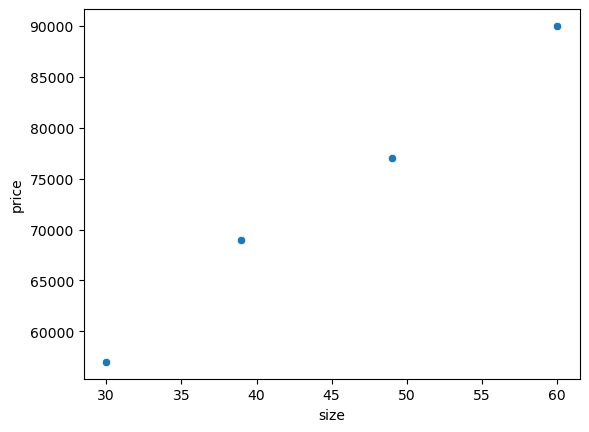

In [ ]:
sns.scatterplot(data=houses_dataset, x="size", y="price")

In [ ]:
houses_determination = houses_cor**2

houses_determination

0.9924156887784898

##### Easy mode

In [16]:
np.cov(houses_size, houses_price)

array([[1.6700e+02, 1.7850e+05],
       [1.7850e+05, 1.9225e+08]])

In [17]:
np.cov(houses_size, houses_price)[0][1]

178500.0

In [18]:
houses_dataset.cov()

,size,price,diff
size,167.0,178500.0,1.850000e+05
price,178500.0,192250000.0,1.612500e+08
diff,185000.0,161250000.0,1.735512e+10


In [19]:
np.corrcoef(houses_size, houses_price)

array([[1.        , 0.99620063],
       [0.99620063, 1.        ]])

In [20]:
houses_dataset.corr()

,size,price,diff
size,1.000000,0.996201,0.108667
price,0.996201,1.000000,0.088278
diff,0.108667,0.088278,1.000000


##### Exercise

In [25]:
houses_dataset = pd.read_csv("data/house_prices.csv")

houses_dataset.drop(
    columns=["id", "date", "sqft_living", "sqft_lot"], axis=1, inplace=True
)

houses_dataset.head()

,price,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [28]:
houses_dataset.corr()

,price,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
price,1.000000,0.308350,0.525138,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.308350,1.000000,0.515884,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.525138,0.515884,1.000000,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
floors,0.256794,0.175429,0.500653,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,0.266369,-0.006582,0.063744,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.397293,0.079532,0.187737,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,0.036362,0.028472,-0.124982,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406
grade,0.667434,0.356967,0.664983,0.458183,0.082775,0.251321,-0.144674,1.000000,0.755923,0.168392,0.446963,0.014414,-0.184862,0.114084,0.198372,0.713202,0.119248
sqft_above,0.605567,0.477600,0.685342,0.523885,0.072075,0.167649,-0.158214,0.755923,1.000000,-0.051943,0.423898,0.023285,-0.261190,-0.000816,0.343803,0.731870,0.194050
sqft_basement,0.323816,0.303093,0.283770,-0.245705,0.080588,0.276947,0.174105,0.168392,-0.051943,1.000000,-0.133124,0.071323,0.074845,0.110538,-0.144765,0.200355,0.017276


<Axes: xlabel='sqft_living15', ylabel='price'>

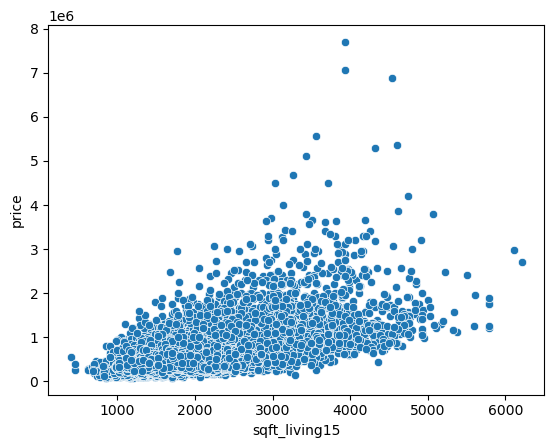

In [ ]:
sns.scatterplot(
    x=houses_dataset["sqft_living15"],
    y=houses_dataset["price"],
)

<Axes: xlabel='grade', ylabel='price'>

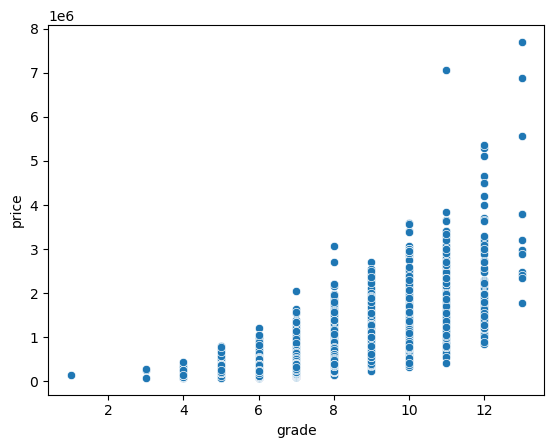

In [ ]:
sns.scatterplot(
    x=houses_dataset["grade"],
    y=houses_dataset["price"],
)

<Axes: xlabel='long', ylabel='price'>

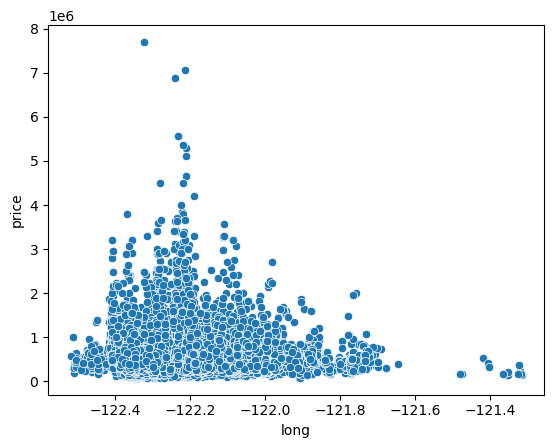

In [ ]:
sns.scatterplot(
    x=houses_dataset["long"],
    y=houses_dataset["price"],
)

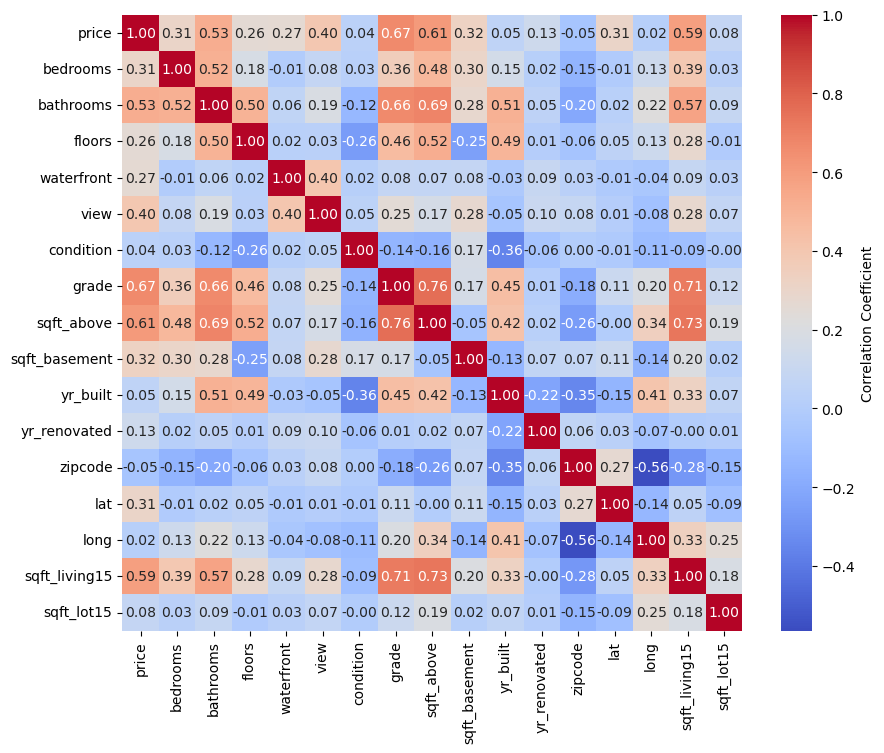

In [47]:
fig, ax = plt.subplots(figsize=(10, 8))

ax = sns.heatmap(
    houses_dataset.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={"label": "Correlation Coefficient"},
)

##### Yellowbrick

In [56]:
houses_dataset.columns

Index(['price', 'bedrooms', 'bathrooms', 'floors', 'waterfront', 'view',
       'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built',
       'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15',
       'sqft_lot15'],
      dtype='object')

In [70]:
houses_dataset.iloc[:, 0:16]

,price,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15
0,221900.0,3,1.00,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340
1,538000.0,3,2.25,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690
2,180000.0,2,1.00,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720
3,604000.0,4,3.00,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360
4,510000.0,3,2.00,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530
21609,400000.0,4,2.50,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830
21610,402101.0,2,0.75,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020
21611,400000.0,3,2.50,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410


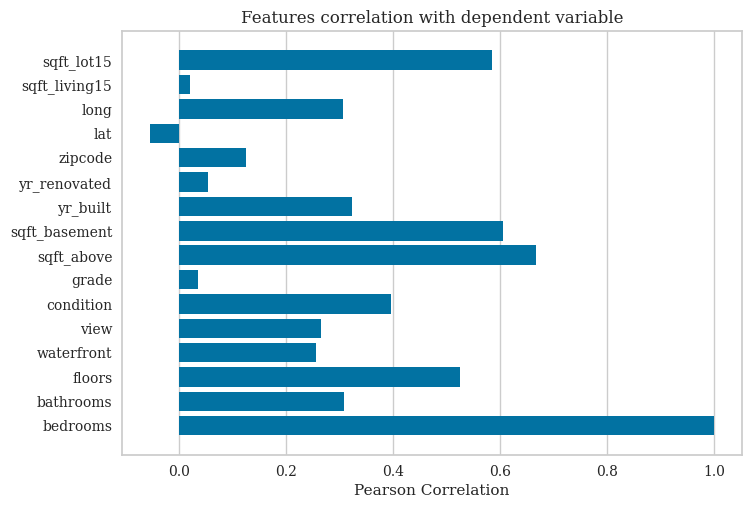

<Axes: title={'center': 'Features correlation with dependent variable'}, xlabel='Pearson Correlation'>

In [75]:
corr_graph = FeatureCorrelation(
    labels=houses_dataset.columns[1:],
)

corr_graph.fit(houses_dataset.iloc[:, 0:16].values, houses_dataset.iloc[:, 0].values)

corr_graph.show()